Number of Outliers: 81
Outlier Percentage: 4.79%
Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - loss: 0.0753 - val_loss: 0.0450
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 0.0321 - val_loss: 0.0489
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - loss: 0.0339 - val_loss: 0.0506
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - loss: 0.0309 - val_loss: 0.0368
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - loss: 0.0306 - val_loss: 0.0448
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - loss: 0.0297 - val_loss: 0.0349
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - loss: 0.0291 - val_loss: 0.0419
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - loss: 0.0285 - val_loss: 0.0786
Epoch 9/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - loss: 0.0291 - val_loss: 0.0624
Epoch 10/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - loss: 0.0269 - val_loss: 0.0392
Epoch 11/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 0.0262 - val_loss: 0.0318
Epoch 12/50
36

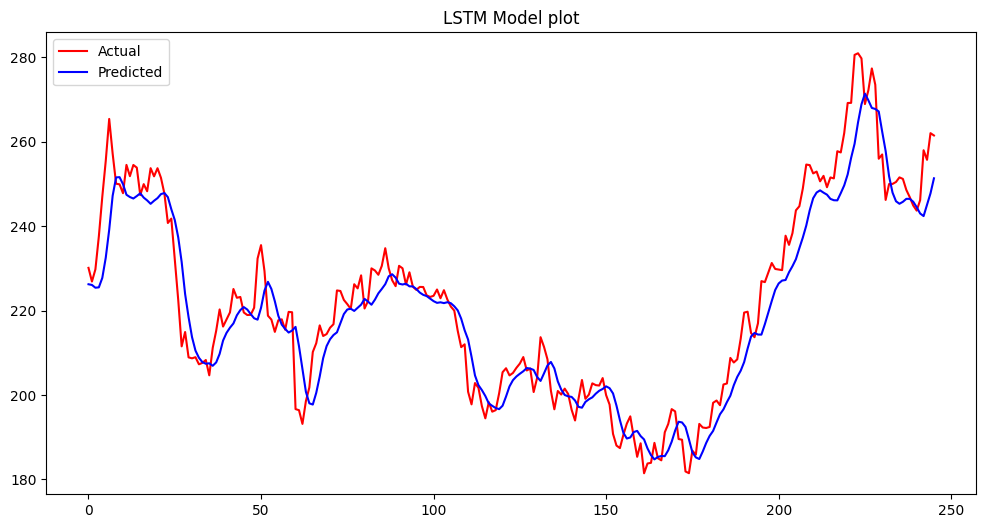

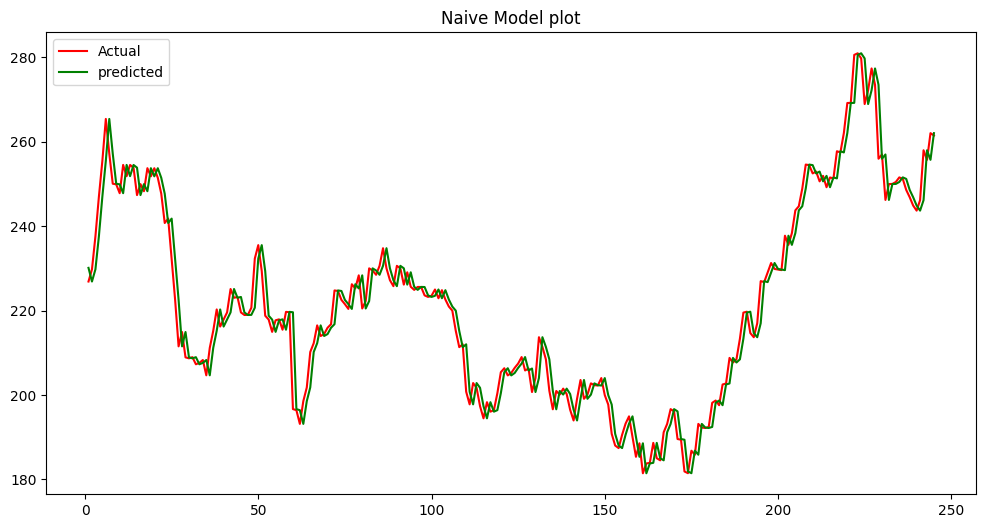

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
LSTM and Naive Minimum, Maximum and Mean Errors
    Model  Minimum Error  Maximum Error  Mean Error
0   LSTM     -19.979721      26.264862    2.439921
1  Naive     -22.949997      11.830002    0.128041

ADF statistic and P Value :
    ADF statistic   P value
0      -0.813733  0.815055

LSTM and Naive Model Comparision :
    Model       MAE      RMSE      MAPE
0   LSTM  5.496686  7.239454  2.441039
1  Naive  3.369101  4.650341  1.522911

LSTM and Naive Prediction Comparision :
               Model  Predicted Price
0   LSTM Prediction       254.081879
1  Naive Prediction       261.500000


In [1]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
df = pd.read_csv(r"D:\Stock Price Analysis Data Science Project\Tesla Stock Price.csv")
df_model = df.copy()

# detect null values
#df_model.describe()
#df_model.info()
df_model.isnull().sum()

# Remove column
df_model = df_model.drop("Adj Close", axis = 1)

# rearange column and change data format
df_model = df_model[["Date","Volume","Open","High","Low","Close"]]
df_model["Date"] = pd.to_datetime(df_model["Date"], format = "mixed")

# Change DataType
col = ["Open","High","Low","Close"]
df_model[col] = df_model[col].astype(float)
df_model["Volume"] = df_model["Volume"].astype(int)

# 4. Outlier Detection Using IQR
df_model["Return"] = df_model["Close"].pct_change()
Q1 = df_model["Return"].quantile(0.25)
Q3 = df_model["Return"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outlier = df_model[(df_model["Return"] < lower) | (df_model["Return"] > upper)]

# find Outlier Percentage
print("Number of Outliers:", len(outlier))
outliers_percentage = (len(outlier) / len(df_model) * 100)
print(f"Outlier Percentage: {outliers_percentage:.2f}%")

# rolling mean and rolling standard diviation
rolling_mean = df_model["Close"].rolling(30).mean()
rolling_std  = df_model["Close"].rolling(30).std()

# ADF - Stationarity Test
from statsmodels.tsa.stattools import adfuller
result = adfuller(df_model["Close"])
Stationarity = pd.DataFrame({"ADF statistic" : [result[0]],
                             "P value"       : [result[1]]})

# Data Preprocessing
# Normalize Data and Scaling

from sklearn.preprocessing import MinMaxScaler
train_end = int(len(df_model) * 0.7)
scaler = MinMaxScaler()
train_data = df_model[["Close"]][:train_end]
scaler.fit(train_data)
scaled_data = scaler.transform(df_model[["Close"]])

# Create Sliding Windows
X = []
y = []
for i in range(60, len(scaled_data)):
    X.append(scaled_data[i-60:i])
    y.append(scaled_data[i])

# LSTM Model Development
# Model Architecture

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

model = Sequential()
model.add(LSTM(50,
               return_sequences = True,
               input_shape = (60,1)))
model.add(Dropout(0.2))
model.add(LSTM(50))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer = "adam",
               loss = "mae")

import numpy as np
X = np.array(X)
y = np.array(y)

# Validation Data Creation

train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)
X_train = X[:train_size]
X_val = X[train_size : train_size + val_size]
X_test = X[train_size + val_size :]

y_train = y[:train_size]
y_val = y[train_size : train_size + val_size]
y_test = y[train_size + val_size :]

# Training
history = model.fit(X_train,
                    y_train,
                    epochs=50,
                    batch_size = 32,
                    validation_data = (X_val,y_val))

# Predict Future Prices
y_pred_lstm = model.predict(X_test)

# inverse
y_pred_lstm = scaler.inverse_transform(y_pred_lstm)
y_test_lstm = scaler.inverse_transform(y_test)

# Model Evaluation
# MAE, MSE, RMSE, MAPE
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
lstm_mae = mean_absolute_error(y_test_lstm, y_pred_lstm)
lstm_mse = mean_squared_error(y_test_lstm, y_pred_lstm)
lstm_rmse = np.sqrt(lstm_mse)
lstm_mape = np.mean(np.abs(y_test_lstm - y_pred_lstm) / y_test_lstm) * 100

# lstm_error
lstm_error = (y_test_lstm - y_pred_lstm)

# Baseline Model Comparison
# Naive Forecast

y_test_naive = pd.Series(y_test_lstm.flatten())
y_pred_naive = y_test_naive.shift(1)

# Baseline Model Comparison
# Remove NaN line
y_pred_naive = y_pred_naive.dropna()
y_test_naive = y_test_naive[1:]

# Model Evaluation
# MAE, MSE, RMSE, MAPE
naive_mae = mean_absolute_error(y_test_naive, y_pred_naive)
naive_mse = mean_squared_error(y_test_naive, y_pred_naive)
naive_rsme = np.sqrt(naive_mse)
naive_mape = np.mean(np.abs(y_test_naive - y_pred_naive) / y_test_naive) * 100

# naive_error
naive_error = (y_test_naive - y_pred_naive)
Errors = pd.DataFrame({"Model" : ["LSTM","Naive"],
                       "Minimum Error" : [np.min(lstm_error), np.min(naive_error)],
                       "Maximum Error" : [np.max(lstm_error), np.max(naive_error)],
                       "Mean Error" : [np.mean(lstm_error), np.mean(naive_error)]
                      })

# LSTM Plot
import matplotlib.pyplot as plt
plt.figure(figsize = (12,6))
plt.title("LSTM Model plot")
plt.plot(y_test_lstm, color = "red")
plt.plot(y_pred_lstm, color = "blue")
plt.legend(["Actual",
            "Predicted"])
plt.savefig("Tesla LSTM Forecast.png", bbox_inches="tight")
plt.show()

# Naive Plot
plt.figure(figsize = (12,6))
plt.title("Naive Model plot")
plt.plot(y_test_naive, color = "red")
plt.plot(y_pred_naive, color = "green")
plt.legend(["Actual",
            "predicted"])
plt.savefig("Tesla Naive Forecast.png", bbox_inches="tight")
plt.show()

# model comparision

comparision = pd.DataFrame({"Model" : ["LSTM","Naive"],
                            "MAE"   : [lstm_mae,naive_mae],
                            "RMSE"  : [lstm_rmse,naive_rsme],
                            "MAPE"  : [lstm_mape,naive_mape]
                           })

# predict next day closing price using LSTM

last_60_days = scaled_data[-60:]
X_next = np.array(last_60_days)
X_next = X_next.reshape(1,60,1)
next_day_scaled_price = model.predict(X_next)
next_day_closing_price = scaler.inverse_transform(next_day_scaled_price)

# predict next day closing price using LSTM

next_day_price = df_model["Close"].iloc[-1]

prediction_comparision = pd.DataFrame({"Model" : ["LSTM Prediction","Naive Prediction"],
                                       "Predicted Price" : [next_day_closing_price[0][0],next_day_price]})

print("LSTM and Naive Minimum, Maximum and Mean Errors\n",Errors)
print("\nADF statistic and P Value :\n",Stationarity)
print("\nLSTM and Naive Model Comparision :\n",comparision)
print("\nLSTM and Naive Prediction Comparision :\n",prediction_comparision)